1. Input Data

In [4]:
import numpy as np
import torch

data = np.load("frozen_soil_sensor_dataset_test.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  
params_arr   = data["params_arr"]    # (n_case, n_param)  
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (220, 61, 49)
all_T_sensor: (220, 61, 11)
params_arr  : (220, 6)
curve_ids   : (220,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. Inverse DeepONet

In [5]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()
params   = torch.from_numpy(params_arr).float()

print("X_sensor for CNN:", X_sensor.shape) 
print("params          :", params.shape)


X_sensor for CNN: torch.Size([220, 11, 61])
params          : torch.Size([220, 6])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        
        self.pool = nn.AdaptiveAvgPool1d(1)  
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          
        
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else:
            
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 64,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim

        self.fc_res = nn.Linear(latent_dim, 1)
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)
        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)
        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1

        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

3. Connect PDE solver

3.1. K and C_eff functions

In [7]:
import torch.nn as nn
import torch.nn.functional as F

n_porosity    = 0.5         
theta_s_fixed = 1.0 - n_porosity   

K_s = 8.80*86400       # W/m/K   
K_w = 0.56*86400       # W/m/K   
K_i = 2.26*86400       # W/m/K   

C_s = 2.13*1e6         # J/m3/K  
C_w = 4.19e6           # J/m3/K  
C_i = 2.13e6           # J/m3/K  

L     = 3.34e5         # J/kg    
rho_w = 1000.0         # kg/m3    


In [8]:

def interp_1d(T_nodes: torch.Tensor,
              T_query: torch.Tensor,
              y_query: torch.Tensor) -> torch.Tensor:
    
    T_min, T_max = T_query[0], T_query[-1]
    T_clamp = torch.clamp(T_nodes, T_min, T_max)

    n_T = T_query.shape[0]
    pos = (T_clamp - T_min) / (T_max - T_min) * (n_T - 1)

    idx0 = torch.floor(pos).long()
    idx1 = torch.clamp(idx0 + 1, max=n_T - 1)
    w    = (pos - idx0.float()).clamp(0.0, 1.0)

    y0 = y_query[idx0]
    y1 = y_query[idx1]
    y  = (1.0 - w) * y0 + w * y1
    return y


def sfcc_and_deriv_finite_diff_batch(
    deeponet: nn.Module,
    X_sensor_batch: torch.Tensor,  # (B, n_sensors, Nt)
    T_query: torch.Tensor,         # (n_T,)
    eps_T: float = 0.2,
    dtheta_max: float = 5.0
):
    
    device = T_query.device
    X_sensor_batch = X_sensor_batch.to(device)
    T_query = T_query.to(device)

    eps = float(eps_T)
    T_min, T_max = T_query[0], T_query[-1]
    T_plus  = torch.clamp(T_query + eps,  T_min, T_max)
    T_minus = torch.clamp(T_query - eps,  T_min, T_max)

    theta_center = deeponet(X_sensor_batch, T_query)   # (B, n_T)
    theta_plus   = deeponet(X_sensor_batch, T_plus)    # (B, n_T)
    theta_minus  = deeponet(X_sensor_batch, T_minus)   # (B, n_T)

    dtheta = (theta_plus - theta_minus) / (2.0 * eps)  # (B, n_T)
    dtheta = torch.clamp(dtheta, 0.0, dtheta_max)

    return theta_center, dtheta



In [9]:

def compute_K_from_theta(theta_w: torch.Tensor) -> torch.Tensor:
   
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    Ks_part = K_s ** theta_s
    Kw_part = K_w ** theta_w
    Ki_part = K_i ** theta_i

    return Ks_part * Kw_part * Ki_part


def compute_Ceff_from_theta_fdiff(
    theta_w: torch.Tensor,      # (Nz,)
    T_nodes: torch.Tensor,      # (Nz,)
    T_query: torch.Tensor,      # (n_T,)
    dtheta_query: torch.Tensor  # (n_T,)
) -> torch.Tensor:
    
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    C_T = theta_s * C_s + theta_w * C_w + theta_i * C_i   # (Nz,)

    dtheta_nodes = interp_1d(T_nodes, T_query, dtheta_query)  # (Nz,)
    C_eff = C_T + L * rho_w * dtheta_nodes
    return C_eff

3.2 PDE solver

In [10]:
def solve_one_case_with_sfcc_fdiff(
    theta_query: torch.Tensor,   # (n_T,)
    dtheta_query: torch.Tensor,  # (n_T,)
    T_query: torch.Tensor,       # (n_T,)
    z: torch.Tensor,             # (Nz,)
    t: torch.Tensor,             # (Nt,)
    T_initial: float,
    T_top_func
) -> torch.Tensor:

    device = theta_query.device
    z = z.to(device)
    t = t.to(device)

    dz  = z[1] - z[0]
    dt  = t[1] - t[0]
    Nz  = z.numel()
    Nt  = t.numel()
    dz2 = dz * dz

    T0 = torch.full((Nz,), float(T_initial),
                    dtype=torch.float32, device=device)
    T_list = [T0]  

    for n in range(Nt - 1):
        Tn = T_list[-1]   

        time_n1     = float(t[n+1].item())
        T_top_n1    = float(T_top_func(time_n1))

        theta_w = interp_1d(Tn, T_query, theta_query)   # (Nz,)
        K_T     = compute_K_from_theta(theta_w)         # (Nz,)
        C_eff   = compute_Ceff_from_theta_fdiff(
            theta_w, Tn, T_query, dtheta_query
        )                                               # (Nz,)

        K_half = 0.5 * (K_T[1:] + K_T[:-1])            # (Nz-1,)

        M = Nz - 2  

        a = torch.zeros(M-1, device=device)
        b = torch.zeros(M,   device=device)
        c = torch.zeros(M-1, device=device)
        d_vec = torch.zeros(M, device=device)

        for j in range(1, Nz-1):
            m = j - 1

            K_left  = K_half[j-1]     # K_{j-1/2}
            K_right = K_half[j]       # K_{j+1/2}
            Ci      = C_eff[j]

            a_m = -K_left  / dz2
            c_m = -K_right / dz2
            b_m = Ci / dt + (K_left + K_right) / dz2
            d_m = Ci / dt * Tn[j]

            if j == 1:
                b_m = b_m + a_m

            if j == Nz-2:
                d_m -= c_m * T_top_n1

            b[m]     = b_m
            d_vec[m] = d_m
            if m > 0:
                a[m-1] = a_m
            if m < M-1:
                c[m] = c_m


        A = torch.diag(b) + torch.diag(a, diagonal=-1) + torch.diag(c, diagonal=1)
        T_internal = torch.linalg.solve(A, d_vec)   # (M,)

        T_next = torch.empty_like(Tn)
        T_next[1:-1] = T_internal
        T_next[0]    = T_next[1]   # zero-flux
        T_next[-1]   = T_top_n1

        T_list.append(T_next)

    T_field = torch.stack(T_list, dim=0)   # (Nt, Nz)
    return T_field


3.3 Connect DeepONet and PDE

In [11]:
class FrozenSoilDM(nn.Module):
    
    def __init__(self,
                 deeponet: nn.Module,
                 z_grid,
                 t_grid,
                 sensor_idx,
                 T_top_func,
                 T_initial: float,
                 theta_sat: float = 0.5,
                 T_min: float = -15.0,
                 T_max: float = 0.0,
                 n_T_query: int = 100):
        super().__init__()

        self.deeponet       = deeponet
        self.T_initial      = T_initial
        self.T_top_func     = T_top_func
        self.theta_sat      = theta_sat

        z_grid = np.asarray(z_grid, dtype=np.float32)
        t_grid = np.asarray(t_grid, dtype=np.float32)
        self.register_buffer("z", torch.from_numpy(z_grid))
        self.register_buffer("t", torch.from_numpy(t_grid))
        self.register_buffer(
            "sensor_idx",
            torch.as_tensor(sensor_idx, dtype=torch.long)
        )

        T_query_np = np.linspace(T_min, T_max, n_T_query).astype("float32")
        self.register_buffer("T_query", torch.from_numpy(T_query_np))

    def forward(self, X_sensor: torch.Tensor):
        device = X_sensor.device
        B, n_sensors, Nt_obs = X_sensor.shape

        z       = self.z.to(device)
        t       = self.t.to(device)
        T_query = self.T_query.to(device)
        idx_s   = self.sensor_idx.to(device)

        Nz = z.numel()
        Nt = t.numel()
        assert Nt_obs == Nt, "The number of observed time steps must be consistent with N_t in t_grid"

        theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
            self.deeponet,
            X_sensor,    # (B, n_sensors, Nt)
            T_query,     # (n_T,)
            eps_T=0.2,
            dtheta_max=5.0
        )  # (B, n_T), (B, n_T)

        T_fields = []
        for b in range(B):
            T_field = solve_one_case_with_sfcc_fdiff(
               theta_query=theta_batch[b],
               dtheta_query=dtheta_batch[b],
               T_query=T_query,
               z=z, t=t,
               T_initial=self.T_initial,
               T_top_func=self.T_top_func
            )
            T_fields.append(T_field)

        T_all = torch.stack(T_fields, dim=0)     # (B, Nt, Nz)
        T_sensor = T_all[:, :, idx_s]   # (B, Nt, n_sensors)

        return T_all, T_sensor


4. Load DeepONet

In [12]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor.shape
latent_dim = 8      
theta_sat = 0.5      

deeponet_eval = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
).to(device)

state_dict = torch.load("deeponet_sfcc_operator_train_80.pt", map_location=device)
deeponet_eval.load_state_dict(state_dict)
deeponet_eval.eval()
print("Loaded DeepONet weights from deeponet_sfcc_operator.pt")


Using device: cuda
Loaded DeepONet weights from deeponet_sfcc_operator.pt


5. Generalization (test)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

latent_dim = 8   
theta_sat = 0.5

deeponet_eval = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
).to(device)

deeponet_eval.load_state_dict(torch.load("deeponet_sfcc_operator_train_80.pt", map_location=device))
deeponet_eval.eval()
print("Loaded DeepONet weights.")


Using device: cuda
Loaded DeepONet weights.


In [14]:
import torch
T_eval_np = np.linspace(-15.0, 0.0, 50).astype("float32")

T_eval = torch.from_numpy(T_eval_np).to(device)          # (n_T_eval,)
X_eval = X_sensor.to(device)                             # (n_case, n_sensors, Nt)

with torch.no_grad():
    theta_pred = deeponet_eval(X_eval, T_eval)           # (n_case, n_T_eval)

theta_pred_np = theta_pred.cpu().numpy()
print("theta_pred_np shape:", theta_pred_np.shape)       # (n_case, 50)


theta_pred_np shape: (220, 50)


In [ ]:
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_excel("T_surface data(Barrow site).xlsx")
T_surf = df.iloc[:, 1].to_numpy(dtype=float)

Nt = len(T_surf)                 
t  = np.arange(Nt, dtype=np.float32)
dt = 1.0

H  = 5.0
dz = 0.1
Nz = int(round(H / dz)) + 1
z  = np.linspace(0, H, Nz).astype(np.float32)

T_initial = -8.0                 
theta_sat = 0.5

def T_top_excel(time_day: float) -> float:
    k = int(time_day)
    if k < 0: k = 0
    if k > Nt - 1: k = Nt - 1
    return float(T_surf[k])

z_torch = torch.from_numpy(z).to(device)
t_torch = torch.from_numpy(t).to(device)

print("Grid:", "Nt =", Nt, "dt =", dt, "| Nz =", Nz, "dz =", dz)

T_query = torch.linspace(-15.0, 0.0, 50, device=device)  
X_eval  = X_sensor.to(device)

with torch.no_grad():
    theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
        deeponet_eval, X_eval, T_query, eps_T=0.2, dtheta_max=5.0
    )  # (n_case, n_T), (n_case, n_T)

print("Inverted SFCC:", theta_batch.shape, dtheta_batch.shape)

n_case = theta_batch.shape[0]
T_pred_list = []

for i in range(n_case):
    Ti = solve_one_case_with_sfcc_fdiff(
        theta_query = theta_batch[i],
        dtheta_query= dtheta_batch[i],
        T_query     = T_query,
        z           = z_torch,
        t           = t_torch,
        T_initial   = float(T_initial),
        T_top_func  = T_top_excel
    )  # (Nt, Nz)
    T_pred_list.append(Ti)

T_pred = torch.stack(T_pred_list, dim=0)     # (n_case, Nt, Nz)
T_pred_np = T_pred.detach().cpu().numpy()
print("T_pred_np:", T_pred_np.shape)

Grid: Nt = 227 dt = 1.0 | Nz = 51 dz = 0.1
Inverted SFCC: torch.Size([220, 50]) torch.Size([220, 50])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

data = np.load("frozen soil_dataset_test_generalizationC.npz")
T_gt_np = data["all_T"]   # (n_case, Nt, Nz)
z = data["z"]             # (Nz,)

assert T_pred_np.shape == T_gt_np.shape

sensor_depths = np.array([1.0, 2.0, 3.0, 4.0])
sensor_idx = np.array([np.argmin(np.abs(z - d)) for d in sensor_depths])
sensor_z = z[sensor_idx]

T_gt_s   = T_gt_np[:, :, sensor_idx]    # (n_case, Nt, 4)
T_pred_s = T_pred_np[:, :, sensor_idx]


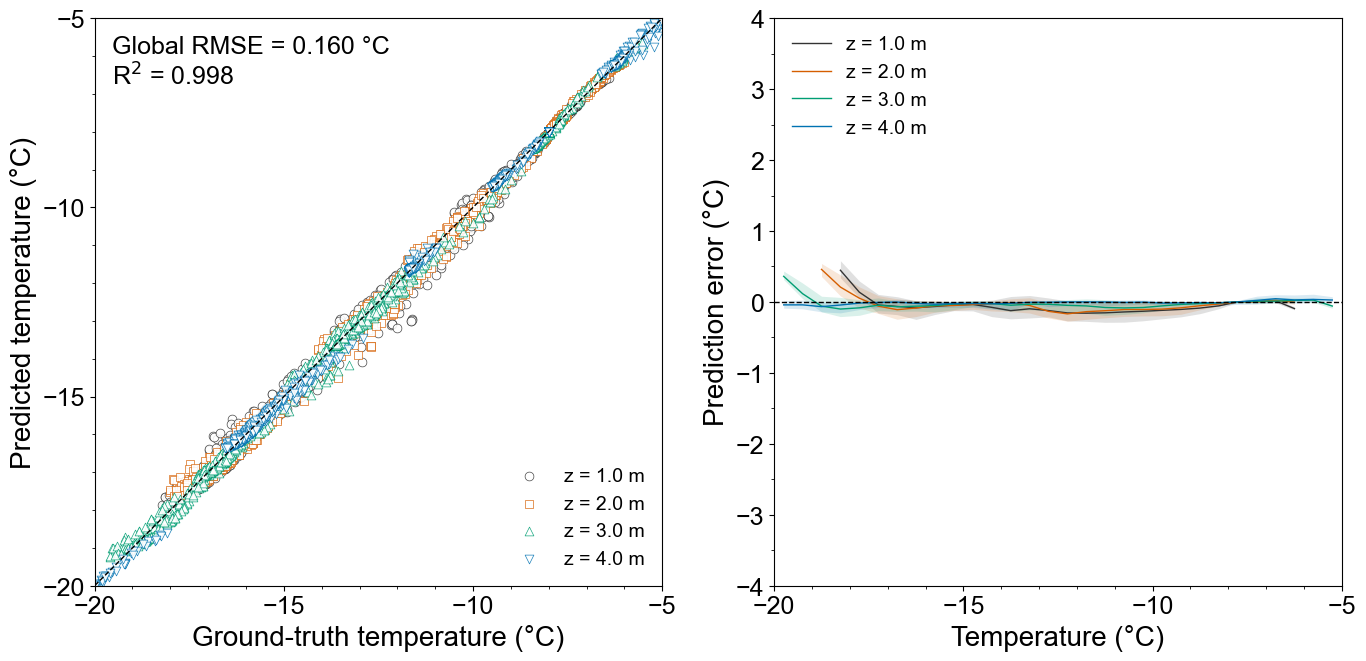

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

y_true_all = np.asarray(T_gt_s).ravel()
y_pred_all = np.asarray(T_pred_s).ravel()
err_all    = y_pred_all - y_true_all

rmse = np.sqrt(np.mean(err_all**2))
ss_res = np.sum((y_true_all - y_pred_all)**2)
ss_tot = np.sum((y_true_all - y_true_all.mean())**2)
r2 = 1.0 - ss_res / (ss_tot + 1e-12)

step_day = 30
Nt = T_gt_s.shape[1]
t_idx_plot = np.arange(0, Nt, step_day, dtype=int)   # 0,5,10,...

T_gt_s_plot   = T_gt_s[:, t_idx_plot, :]    # (n_case, Nt_plot, 4)
T_pred_s_plot = T_pred_s[:, t_idx_plot, :]  # (n_case, Nt_plot, 4)

depths = np.asarray(sensor_depths).astype(float)  # (4,)

markers = {
    1.0: "o",   # circle
    2.0: "s",   # square
    3.0: "^",   # triangle up
    4.0: "v",   # triangle down
}

colors = {
    1.0: "#333333",  # near black
    2.0: "#D55E00",  # muted orange/red
    3.0: "#009E73",  # teal/green
    4.0: "#0072B2",  # muted blue
}

bin_width = 0.5
bins = np.arange(-20.0, -5.0 + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

min_count = 30  

stats = {}  # depth -> (median, q25, q75)
for j, d in enumerate(depths):
    y_true = np.asarray(T_gt_s[:, :, j]).ravel()
    y_pred = np.asarray(T_pred_s[:, :, j]).ravel()
    err    = y_pred - y_true

    med = np.full_like(bin_centers, np.nan, dtype=float)
    q25 = np.full_like(bin_centers, np.nan, dtype=float)
    q75 = np.full_like(bin_centers, np.nan, dtype=float)

    for i, (b0, b1) in enumerate(zip(bins[:-1], bins[1:])):
        m = (y_true >= b0) & (y_true < b1)
        if np.sum(m) >= min_count:
            e = err[m]
            med[i] = np.median(e)
            q25[i] = np.percentile(e, 25)
            q75[i] = np.percentile(e, 75)

    stats[float(d)] = (med, q25, q75)

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 18
mpl.rcParams["axes.labelsize"] = 20
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 14

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax in axes:
    ax.set_box_aspect(1)
    ax.grid(False)

ax = axes[0]

for j, d in enumerate(depths):
    y_true = np.asarray(T_gt_s_plot[:, :, j]).ravel()
    y_pred = np.asarray(T_pred_s_plot[:, :, j]).ravel()

    ax.scatter(
        y_true, y_pred,
        s=40,
        marker=markers[float(d)],
        facecolors="white",                
        edgecolors=colors[float(d)],       
        linewidths=0.5,
        alpha=0.9,
        label=f"z = {d:.1f} m"
    )

ax.plot([-20, -5], [-20, -5], "k--", lw=1.0)
ax.set_xlim(-20, -5)
ax.set_ylim(-20, -5)
ax.set_xlabel("Ground-truth temperature (°C)")
ax.set_ylabel("Predicted temperature (°C)")

ax.text(
    0.03, 0.97,
    f"Global RMSE = {rmse:.3f} °C\n"
    f"R$^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="left", va="top"
)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))

ax.legend(frameon=False, loc="lower right")

ax = axes[1]

for d in depths:
    med, q25, q75 = stats[float(d)]
    c = colors[float(d)]

    
    ax.fill_between(
        bin_centers, q25, q75,
        color=c, alpha=0.15, linewidth=0
    )
    ax.plot(
        bin_centers, med,
        color=c, lw=1.0,
        label=f"z = {d:.1f} m"
    )

ax.axhline(0.0, color="k", linestyle="--", lw=1.0)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Prediction error (°C)")

ax.set_xlim(-20, -5)
ax.set_ylim(-4, 4)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()